<a href="https://colab.research.google.com/github/Adriungs/SQL/blob/main/SQL_B%C3%81SICO/5_Alias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font size = '4'><u><b>FRAGMENTACION DE DATAFRAME</b></u></font>
</center>

En este caso las explicaciónes de los codigos de python no son importantes,sin embargo, si voy a detallar que lo que hizo el codigo en python es crearme 3 tablas dividiendo el contenido del archivo.

 **¿Porque fragmentamos el dataframe?**

  Como necesitamos unir multiples tablas para futuras prácticas lo conveniente es dividirlo usando solo una base de datos.

Otras bases de datos podrian no estar correlacionadas y estaremos juntando datos diferentes ó que nada tienen que ver con lo que estamos analizando.

En las aplicaciones reales se usan multiples tablas de diferentes sectores eso es lo que hicimos al fragmentar.

Si lo pensamos en aplicaciones reales hay tres sectores que requieren diferentes tablas:


1.   Clientes
2.   Productos
3.   Ventas



In [2]:
#Nueva base de datos
!pip install jupysql --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 18.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import sqlite3

# 1. Cargar el archivo con tus columnas reales
df_original = pd.read_csv('retail_ferreteria.csv')

# 2. Normalización ajustada a tu dataset

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

# 3. Guardar en el motor SQLite
conn = sqlite3.connect('ferreteria.db')

try:
  clientes.to_sql('clientes', conn, if_exists='replace', index=False)
  productos.to_sql('productos', conn, if_exists='replace', index=False)
  ventas.to_sql('ventas', conn, if_exists='replace', index=False)
finally:
    conn.close()  # <-- Esto libera el archivo y evita el error "database is locked"

print("¡Base de datos 'ferreteria.db' creada y liberada con éxito!")



¡Base de datos 'ferreteria.db' creada y liberada con éxito!


In [4]:
%load_ext sql
%sql sqlite:///ferreteria.db
%config SqlMagic.feedback = False
%config SqlMagic.displaylimit = 0

Connecting to 'sqlite:///ferreteria.db'

<center>
<font size = '6' color =black><u><b>Alias y operaciones simples<b/></u></font>
</center>

Este capitulo puede ser uno de los pocos que no va a tener ejercicios sin embargo lo deje en este repositorio porque pese a no tener proyecto es muy importante para escritura avanzada.Ya que te ahorra mucho trabajo visual al leerlo y es mucho más practico.En el apartado de Join esto se usa mucho, vamos a adelantarnos y al final de esta sección vamos a poner un ejemplo.

Hasta ahora se implemento lo siguiente:

* Mostrar todas las columnas (SELECT *).
* Elegir columnas específicas.
* Filtrar resultados (WHERE, AND, OR, NOT).
* Ordenar y limitar resultados (ORDER BY, LIMIT).

Pero a veces necesitamos que los resultados sean más fáciles de leer o que incluyan cálculos sencillos directamente en la consulta.

Para eso usamos:

* Alias (AS) → para renombrar columnas o tablas en el resultado.
* Operaciones simples → para realizar cálculos matemáticos sobre columnas


<center>
<font size = '6' color =black><u><b> ¿Qué es un alias (AS)?<b/></u></font>
</center>

Un alias es un nombre alternativo que le damos a una columna o tabla solo en el resultado de la consulta.


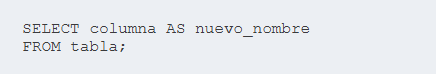

<u><b>Ejemplo 1: renombrar una columna:</b></u>



In [5]:
#Como la columna se llama productos parecido a la tabla le voy a cambiar el nombre
%%sql
SELECT producto AS herramientas
FROM productos
LIMIT 5

herramientas
Caja de tornillos
Taladro eléctrico
Sierra circular
Llave inglesa
Sierra circular


<u><b>Ejemplo 2: renombrar varias columnas:</b></u>



In [6]:
%%sql
SELECT producto AS herramientas, precio_unitario AS precio_cadauno
FROM productos
LIMIT 5

herramientas,precio_cadauno
Caja de tornillos,11937.33
Taladro eléctrico,5591.07
Sierra circular,14631.34
Llave inglesa,6008.3
Sierra circular,7116.48


<u><b>Ejemplo 3: alias para tablas</b></u>

Si una tabla tiene un nombre muy largo, podemos darle un alias corto:





In [10]:
%%sql
SELECT p.producto, p.categoria  --Aca le estoy indicando de la tabla p buscame producto
FROM productos AS p
LIMIT 5

producto,categoria
Caja de tornillos,Fijaciones
Taladro eléctrico,Herramientas eléctricas
Sierra circular,Herramientas eléctricas
Llave inglesa,Herramientas manuales
Sierra circular,Herramientas eléctricas


**Usualmente se usa la abreviatura con JOIN por ejemplo:**



SELECT p.producto, c.nombre_categoria

FROM productos AS p

INNER JOIN categorias AS c                                                                      
    ON p.id_categoria = c.id_categoria

LIMIT 5;

Esto es un ejemplo luego veremos JOIN en SQL intermedio

<center>
<font size = '6' color =black><u><b>Operaciones simples en SQL<b/></u></font>
</center>

Además de renombrar, también podemos hacer cálculos en el SELECT.


<u><b>Ejemplos de operaciones:</b></u>
* Sumar → edad + 1
* Restar → edad - 2
* Multiplicar → edad * 2
* Dividir → edad / 2

<u><b>Ejemplo 4: sumar un valor a una columna:</b></u>


In [14]:
%%sql
SELECT producto, precio_unitario +1000 AS nuevo_precio
FROM productos
LIMIT 5

producto,nuevo_precio
Caja de tornillos,12937.33
Taladro eléctrico,6591.07
Sierra circular,15631.34
Llave inglesa,7008.3
Sierra circular,8116.48
